In [0]:
import warnings 
warnings.filterwarnings('ignore')

In [2]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [3]:
import numpy as np
import pandas as pd
import math
import json
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.externals import joblib
import scipy.sparse
from scipy.sparse import csr_matrix
import warnings; warnings.simplefilter('ignore')
%matplotlib inline

/usr/local/lib/python3.6/dist-packages/sklearn/externals/joblib/__init__.py:15: DeprecationWarning: sklearn.externals.joblib is deprecated in 0.21 and will be removed in 0.23. Please import this functionality directly from joblib, which can be installed with: pip install joblib. If this warning is raised when loading pickled models, you may need to re-serialize those models with scikit-learn 0.21+.
  warnings.warn(msg, category=DeprecationWarning)


##Look at the data and infer possible details
### Q1. Read and explore the dataset

(Rename column, plot histograms, find data characteristics)

In [0]:
#Import the data set
df = pd.read_csv('/content/drive/My Drive/Colab Notebooks/ratings_Electronics.csv', header=None)
df.columns = ['user_id', 'prod_id', 'rating', 'timestamp']

In [5]:
#view the first few rows
df.head(5)

,user_id,prod_id,rating,timestamp
0,AKM1MP6P0OYPR,0132793040,5.0,1365811200
1,A2CX7LUOHB2NDG,0321732944,5.0,1341100800
2,A2NWSAGRHCP8N5,0439886341,1.0,1367193600
3,A2WNBOD3WNDNKT,0439886341,3.0,1374451200
4,A1GI0U4ZRJA8WN,0439886341,1.0,1334707200


In [6]:
# Remove timestamp column. We do not need it
if 'timestamp' in df.columns:
    df = df.drop('timestamp', axis=1)
df.head(5)

,user_id,prod_id,rating
0,AKM1MP6P0OYPR,0132793040,5.0
1,A2CX7LUOHB2NDG,0321732944,5.0
2,A2NWSAGRHCP8N5,0439886341,1.0
3,A2WNBOD3WNDNKT,0439886341,3.0
4,A1GI0U4ZRJA8WN,0439886341,1.0


In [7]:
#Check the shape of the dataset
df.shape

(7824482, 3)

There are 7824482 rows and 3 coulmns after removing timestamp column

In [8]:
print('DataTypes:')
print(df.dtypes)
print("")

print('Info:')
print(df.info())
print("")

print('columns:')
print(df.columns)
print("")

print('shape:')
print(df.shape)
print("")

print('IsNull?:')
print(df.isnull().values.any())
print('no of nulls: ', df.isnull().sum())
print("")

print('IsNA?:')
print(df.isna().values.any())
print('no of NAs: ', df.isna().sum())
print("")

print("Number of NULL values in each column:")
print(df.isnull().apply(sum))
print(df.isna().apply(sum))

print('Check for zeroes in the data')
print(('No of zeros', ((df==0).sum().to_frame().T)))
print("")

DataTypes:
user_id     object
prod_id     object
rating     float64
dtype: object

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7824482 entries, 0 to 7824481
Data columns (total 3 columns):
user_id    object
prod_id    object
rating     float64
dtypes: float64(1), object(2)
memory usage: 179.1+ MB
None

columns:
Index(['user_id', 'prod_id', 'rating'], dtype='object')

shape:
(7824482, 3)

IsNull?:
False
no of nulls:  user_id    0
prod_id    0
rating     0
dtype: int64

IsNA?:
False
no of NAs:  user_id    0
prod_id    0
rating     0
dtype: int64

Number of NULL values in each column:
user_id    0
prod_id    0
rating     0
dtype: int64
user_id    0
prod_id    0
rating     0
dtype: int64
Check for zeroes in the data
('No of zeros',    user_id  prod_id  rating
0        0        0       0)



There is no null or missing data.
User ID and prod ID are objects, Ratings is a float type

In [9]:
#No of unique users
df['user_id'].nunique()

4201696

In [10]:
#No of unique products
df['prod_id'].nunique()

476002

The no of users in the database  is 4201696

The no of products in the database  is 476002

In [11]:
# Analyze the ratings 
print('The minimum rating provided by any user is: ', df['rating'].min())
print('The maximum rating provided by any user is: ', df['rating'].max())

The minimum rating provided by any user is:  1.0
The maximum rating provided by any user is:  5.0


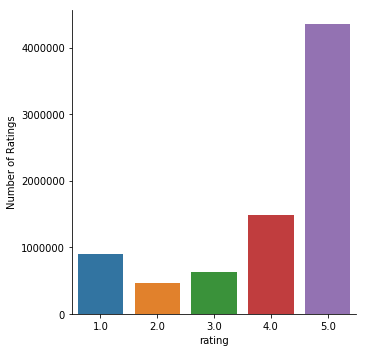

In [12]:
# Ratings distribution 
g = sns.factorplot("rating", data=df, kind='count')
g.set_ylabels("Number of Ratings") 

Based on the histogram, the number of 5 star ratings is much higher than other ratings. 

Looks like more customers are happy with most of their products

##Handle Outliers

In the given dataset there are only 3 columns. 

Product ID and user ID are unique to each product and each user respectively. Outlier means nothing in this since it is an identity.

Ratings vary from 1 to 5 and they are hierachial class and there is no scope of ourliers in such data. 

**Hence no need of outier handling in the given dataset**

## Q2. Take subset of dataset to make it less sparse/more dense. 
( For example, keep the users only who has given 50 or more number of ratings )

In [13]:
# Top 10 users based on the number of ratings
df['user_id'].value_counts().sort_values(ascending=False)[:10]

A5JLAU2ARJ0BO     520
ADLVFFE4VBT8      501
A3OXHLG6DIBRW8    498
A6FIAB28IS79      431
A680RUE1FDO8B     406
A1ODOGXEYECQQ8    380
A36K2N527TXXJN    314
A2AY4YUOX2N1BQ    311
AWPODHOB4GFWL     308
A25C2M3QF9G7OQ    296
Name: user_id, dtype: int64

In [14]:
# Top 10 products based on the number of ratings it received, irrespective of good or bad ratings it received 
df['prod_id'].value_counts().sort_values(ascending=False)[:10]

B0074BW614    18244
B00DR0PDNE    16454
B007WTAJTO    14172
B0019EHU8G    12285
B006GWO5WK    12226
B003ELYQGG    11617
B003ES5ZUU    10276
B007R5YDYA     9907
B00622AG6S     9823
B0002L5R78     9487
Name: prod_id, dtype: int64

### Check the no of users who has given 50 or more number of ratings

In [0]:
counts = df['user_id'].value_counts()
data = df[df['user_id'].isin(counts[counts >= 50].index)]

In [16]:
#number of users who have rated atleast 50 times 
np.shape(data)

(125871, 3)

125871 users have given atleast 50 ratings

### Check the no of users who has given 55 or more number of ratings

In [17]:
counts = df['user_id'].value_counts()
data = df[df['user_id'].isin(counts[counts >= 55].index)]
np.shape(data)

(110481, 3)

110481 users have given atleast 55 ratings

### Check the no of users who has given 60 or more number of ratings

In [18]:
counts = df['user_id'].value_counts()
data = df[df['user_id'].isin(counts[counts >= 60].index)]
np.shape(data)

(96416, 3)

96416 users have given atleast 60 ratings

### Keep data with users who has given 60 or more number of ratings

In [19]:
#number of users in the final data that has atleats 60 reviews from a customer
data['user_id'].nunique()

996

In [20]:
#number of products in the final data that has atleats 60 reviews from a customer
data['prod_id'].nunique()

39598

### Q3. Split the data randomly into train and test dataset
(For example split it in 70/30 ratio)

In [0]:
#Split the training and test data in the ratio 70:30
train_data, test_data = train_test_split(data, test_size = 0.3, random_state=89)

In [22]:
np.shape(train_data)

(67491, 3)

In [23]:
np.shape(test_data)

(28925, 3)

### Q4. Build Popularity Recommender model. 

In [24]:
#Count of user_id for each unique product as recommendation score 
g_train = train_data.groupby('prod_id').agg({'user_id': 'count'}).reset_index()
g_train.rename(columns = {'user_id': 'score'},inplace=True)
g_train.head()

,prod_id,score
0,0970407998,2
1,1400501466,1
2,1400501520,1
3,1400501776,1
4,1400532620,1


In [25]:
#Sort the products on recommendation score 
sorted_train = g_train.sort_values(['score', 'prod_id'], ascending = [0,1]) 
sorted_train.head()

,prod_id,score
25181,B0088CJT4U,118
16208,B003ES5ZUU,97
7277,B000N99BBC,92
24952,B00829TIEK,91
25381,B008DWCRQW,90


In [0]:
# Recommendation rank based on score 
sorted_train['Rank'] = sorted_train['score'].rank(ascending=0, method='first')

In [0]:
#Top 5 recommendations 
popular = sorted_train.head(5)

In [0]:
# Use popularity based recommender model to make predictions
def recommend(user_id):     
    user_reco = popular 
          
    #Add user_id for the recommendations
    user_reco['user_id'] = user_id 
      
    #user_id column must be the first column
    cols = user_reco.columns.tolist() 
    cols = cols[-1:] + cols[:-1] 
    user_reco = user_reco[cols] 
          
    return user_reco

In [29]:
find_recom = [5,888,7914,67491,54001, 1491]   # This list is user choice.
for i in find_recom:
    print("Here is the recommendation for the userId: %d\n" %(i))
    print(recommend(i))    
    print("")
    print("")

Here is the recommendation for the userId: 5

       user_id     prod_id  score  Rank
25181        5  B0088CJT4U    118   1.0
16208        5  B003ES5ZUU     97   2.0
7277         5  B000N99BBC     92   3.0
24952        5  B00829TIEK     91   4.0
25381        5  B008DWCRQW     90   5.0


Here is the recommendation for the userId: 888

       user_id     prod_id  score  Rank
25181      888  B0088CJT4U    118   1.0
16208      888  B003ES5ZUU     97   2.0
7277       888  B000N99BBC     92   3.0
24952      888  B00829TIEK     91   4.0
25381      888  B008DWCRQW     90   5.0


Here is the recommendation for the userId: 7914

       user_id     prod_id  score  Rank
25181     7914  B0088CJT4U    118   1.0
16208     7914  B003ES5ZUU     97   2.0
7277      7914  B000N99BBC     92   3.0
24952     7914  B00829TIEK     91   4.0
25381     7914  B008DWCRQW     90   5.0


Here is the recommendation for the userId: 67491

       user_id     prod_id  score  Rank
25181    67491  B0088CJT4U    118   1.0
1

In a popularity-based recommender model, recommendations may remain the same for all users asin this dataset 

Here the popularity is not considering geoography, ethnicity, language and similar factors. In the whole database, the most popular ones are recommended, irrespective of whether the user likes the genre, language, etc.,

The recommednations are not personalized for a given user

### Q5. Build Collaborative Filtering model on the sampled data (users given > 60 ratings)

collaborative filtering is a method to predict a rating for a user item pair based on the history of ratings given by the user and given to the item.

In [30]:
df_collab_filter = pd.concat([train_data, test_data]).reset_index()
df_collab_filter.head()

,index,user_id,prod_id,rating
0,2071218,A1PL7QILVQV3IF,B001HSOFI2,4.0
1,1147514,A1J75JJ0Q2OEJN,B000M1C0OQ,4.0
2,457221,A1IG1I6MR3HAWA,B0002DA91U,1.0
3,1393519,A3OA4DV4L81N1D,B000UF24OK,5.0
4,248515,A1A5KUIIIHFF4U,B00008KYHC,5.0


In [31]:
#rows are 'user's and columns are 'item's
pivot_df = df_collab_filter.pivot(index = 'user_id', columns ='prod_id', values = 'rating').fillna(0)
pivot_df['user_index'] = np.arange(0, pivot_df.shape[0], 1)
pivot_df.shape

(996, 39599)

In [32]:
pivot_df.set_index(['user_index'], inplace=True)

# Actual ratings given by users
pivot_df.head()

prod_id,0594481813,0970407998,0972683275,1400501466,1400501520,1400501776,1400532620,1400532655,140053271X,1400599997,1400698987,1400699169,1685560148,7562434166,787988002X,8862935307,8862936826,9043413585,9573212900,9573212919,9575871979,9800359788,9981719005,9981739588,9983722615,998376234X,9983891212,9984922626,9985511298,9985525264,9985696999,9989360391,B000000O48,B000001OKH,B000001OL6,B000001OM4,B000001OM5,B000001OMI,B000001OMN,B000001OMZ,...,B00KR0QHXW,B00KR6FY94,B00KRI1AP4,B00KSBB84S,B00KSTODWY,B00KT17TZ4,B00KTIYN7O,B00KU4RD4M,B00KVLY8E2,B00KVNY2KA,B00KW2W6B2,B00KW3OFG0,B00KWHMR6G,B00KWL62QI,B00KWMNDDM,B00KWPRSJY,B00KWWY1PQ,B00KXAFYZS,B00KXMN08E,B00KXUHX9S,B00KYA7CT8,B00KYMCJF8,B00L0YFJHY,B00L1I727Y,B00L1I80K2,B00L1NZTSS,B00L21HC7A,B00L2442H0,B00L26YDA4,B00L2P3TRS,B00L3YHF6O,B00L403O94,B00L43HAY6,B00L5YZCCG,B00L8I6SFY,B00LA6T0LS,B00LBZ1Z7K,B00LGQ6HL8,B00LI4ZZO8,B00LKG1MC8
user_index,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


#### Model-based Collaborative Filtering: Singular Value Decomposition

SVD in the context of recommendation systems is used as a collaborative filtering algorithm.

Most CF algorithms are based on user-item rating matrix where each row represents a user, each column an item. The entries of this matrix are ratings given by users to items.

In [0]:
from scipy.sparse.linalg import svds

# Singular Value Decomposition
U, sigma, Vt = svds(pivot_df, k = 50)
# Construct diagonal array in SVD
sigma = np.diag(sigma)

In [34]:
# Predicted ratings
ratings_all_user_predicted = np.dot(np.dot(U, sigma), Vt) 

preds_df = pd.DataFrame(ratings_all_user_predicted, columns = pivot_df.columns)
preds_df.head()

prod_id,0594481813,0970407998,0972683275,1400501466,1400501520,1400501776,1400532620,1400532655,140053271X,1400599997,1400698987,1400699169,1685560148,7562434166,787988002X,8862935307,8862936826,9043413585,9573212900,9573212919,9575871979,9800359788,9981719005,9981739588,9983722615,998376234X,9983891212,9984922626,9985511298,9985525264,9985696999,9989360391,B000000O48,B000001OKH,B000001OL6,B000001OM4,B000001OM5,B000001OMI,B000001OMN,B000001OMZ,...,B00KR0QHXW,B00KR6FY94,B00KRI1AP4,B00KSBB84S,B00KSTODWY,B00KT17TZ4,B00KTIYN7O,B00KU4RD4M,B00KVLY8E2,B00KVNY2KA,B00KW2W6B2,B00KW3OFG0,B00KWHMR6G,B00KWL62QI,B00KWMNDDM,B00KWPRSJY,B00KWWY1PQ,B00KXAFYZS,B00KXMN08E,B00KXUHX9S,B00KYA7CT8,B00KYMCJF8,B00L0YFJHY,B00L1I727Y,B00L1I80K2,B00L1NZTSS,B00L21HC7A,B00L2442H0,B00L26YDA4,B00L2P3TRS,B00L3YHF6O,B00L403O94,B00L43HAY6,B00L5YZCCG,B00L8I6SFY,B00LA6T0LS,B00LBZ1Z7K,B00LGQ6HL8,B00LI4ZZO8,B00LKG1MC8
0,0.000939,0.003995,-0.002557,0.007443,0.007679,0.029374,0.000356,0.005962,0.006286,-0.001264,0.009168,0.012103,-2.026387e-07,0.003814,0.019124,0.006414,-0.008061,-0.048263,0.006347,-0.002894,0.000858,0.010582,0.031322,0.017981,0.003569,0.020901,-0.005768,-0.001234,0.000899,0.003015,0.004009,0.012541,0.000844,0.005816,0.004811,0.008526,0.012737,-0.037475,-0.000311,0.003015,...,0.010648,0.004177,0.027478,0.001066,-0.043683,0.019975,0.039304,-0.005194,0.082574,0.306626,0.024437,0.020367,-0.000357,0.307578,-0.019841,0.013176,0.026343,0.212129,0.016676,-0.000504,-0.009038,0.188661,0.082574,-0.103696,0.028018,-0.000315,0.399530,0.153824,0.194958,-0.082957,0.223534,0.007537,-0.060468,0.000595,-0.069713,-0.120418,0.016487,-0.189512,0.016961,-0.009038
1,-0.005313,-0.003331,0.071102,0.011151,-0.002686,0.058462,0.000134,-0.003945,-0.001683,0.026694,0.008575,0.003522,3.934585e-03,-0.003281,-0.014808,-0.004774,0.008423,-0.000228,-0.006130,0.006144,0.001124,-0.014535,0.001991,0.005259,-0.002051,0.010681,-0.002862,0.002659,-0.000560,-0.000850,-0.000528,0.006067,0.000985,0.028050,0.007592,0.003611,0.006904,-0.004147,0.000859,-0.000850,...,-0.002717,-0.001700,-0.066497,0.001313,-0.026064,0.072837,0.106758,-0.059403,-0.037573,0.021093,0.013983,-0.076053,0.012414,0.005692,0.003724,0.040705,-0.060399,0.187891,-0.026044,-0.001030,0.038117,-0.113935,-0.037573,0.037485,0.016459,0.011777,-0.015543,-0.026840,0.006119,0.029988,-0.146930,-0.025422,0.032221,-0.000534,-0.004151,0.006760,-0.039898,-0.027231,-0.021018,0.038117
2,-0.005740,-0.004985,0.032017,0.009016,-0.001833,0.008203,0.000021,-0.004585,-0.001122,0.010230,-0.000489,-0.044600,-3.791787e-03,-0.001594,-0.004502,-0.002992,0.019765,0.023665,-0.005566,-0.004162,-0.001382,-0.044638,0.007084,-0.004802,-0.000203,-0.016556,0.008828,-0.001099,-0.000464,-0.002099,0.000546,-0.003535,0.000417,-0.005048,-0.005828,0.004463,-0.000379,-0.020769,0.000097,-0.002099,...,-0.002489,-0.000990,0.015535,0.000620,-0.019825,0.015762,-0.001651,0.053234,-0.046327,0.012038,0.014678,0.051610,0.007672,-0.022898,0.086562,0.005643,-0.063085,-0.057259,0.011094,0.000209,-0.008107,0.088849,-0.046327,-0.019920,0.073872,0.019737,-0.103077,0.007743,-0.011636,-0.015936,-0.170419,0.019734,0.009794,-0.001590,-0.038597,-0.042402,0.009321,0.070785,-0.101439,-0.008107
3,0.010929,-0.005776,-0.002735,0.001067,0.004081,-0.001669,0.000036,0.004131,0.003057,0.000676,0.009390,-0.007118,1.215117e-02,0.002896,0.015086,0.011514,-0.001527,-0.012193,0.007140,0.004950,0.004526,-0.025947,-0.000553,0.010852,0.001573,0.032000,0.010276,0.000533,0.000943,0.001625,0.000464,0.002782,-0.000071,0.002454,0.006850,0.005512,0.004487,0.044448,-0.000007,0.001625,...,0.005540,0.002219,0.025173,0.000382,0.045822,0.035085,-0.022995,-0.024635,-0.009660,-0.020508,-0.003965,0.027282,-0.000827,-0.037040,-0.029238,0.004372,0.029769,0.058251,-0.018728,-0.000244,-0.024858,-0.034093,-0.009660,-0.018579,-0.033840,0.003288,0.124998,0.034963,0.113089,-0.014863,-0.095117,0.002177,0.006330,0.000801,-0.002699,-0.031441,0.015104,0.006120,-0.007926,-0.024858
4,-0.002377,0.009937,0.028209,0.008032,0.002703

In [35]:
preds_df.shape

(996, 39598)

In [0]:
# Recommend the items with the highest predicted ratings
def recommend_items(userID, pivot_df, preds_df, num_recommendations):      
    user_idx = userID-1 # index starts at 0
    
    # Get and sort the user's ratings
    sorted_user_ratings = pivot_df.iloc[user_idx].sort_values(ascending=False)
    #sorted_user_ratings
    sorted_user_predictions = preds_df.iloc[user_idx].sort_values(ascending=False)
    #sorted_user_predictions

    temp = pd.concat([sorted_user_ratings, sorted_user_predictions], axis=1)
    temp.index.name = 'Recommended Items'
    temp.columns = ['user_ratings', 'user_predictions']
    
    temp = temp.loc[temp.user_ratings == 0]   
    temp = temp.sort_values('user_predictions', ascending=False)
    print('Below are the recommended items for user ID: ', userID)
    print(temp.head(num_recommendations))

In [37]:
find_recom = [5,888, 996, 100, 575, 50]   # Selected users to whom recommendation needs to be provided
num_recommendations = 5
for i in find_recom:
    print("")
    recommend_items(i, pivot_df, preds_df, num_recommendations)


Below are the recommended items for user ID:  5
                   user_ratings  user_predictions
Recommended Items                                
B003ES5ZUU                  0.0          0.897026
B0088CJT4U                  0.0          0.878379
B000N99BBC                  0.0          0.676308
B008DWCRQW                  0.0          0.608461
B00829TIEK                  0.0          0.514151

Below are the recommended items for user ID:  888
                   user_ratings  user_predictions
Recommended Items                                
B002R5AM7C                  0.0          1.338092
B004CLYEFK                  0.0          1.271774
B00HFRWWAM                  0.0          1.043359
B008DWCRQW                  0.0          0.968683
B004T9RR6I                  0.0          0.907950

Below are the recommended items for user ID:  996
                   user_ratings  user_predictions
Recommended Items                                
B00AKONZ3U                  0.0          2.380485

### Q6. Evaluate both the models. 
Once the model is trained on the training data, it can be used to compute the error (RMSE) on predictions made on the test data

In [38]:
final_ratings_matrix = data.pivot(index = 'user_id', columns ='prod_id', values = 'rating').fillna(0)
final_ratings_matrix.shape

(996, 39598)

In [39]:
given_num_of_ratings = np.count_nonzero(final_ratings_matrix)
given_num_of_ratings

96416

In [40]:
possible_num_of_ratings = final_ratings_matrix.shape[0] * final_ratings_matrix.shape[1]
possible_num_of_ratings

39439608

In [41]:
density = (given_num_of_ratings/possible_num_of_ratings) * 100
density

0.2444649044179141

In [42]:
# Actual ratings given by the users
final_ratings_matrix.shape

(996, 39598)

In [43]:
# Average actual rating for each product
final_ratings_matrix.mean()

prod_id
0594481813    0.003012
0970407998    0.005020
0972683275    0.005020
1400501466    0.009036
1400501520    0.005020
1400501776    0.009036
1400532620    0.001004
1400532655    0.008032
140053271X    0.005020
1400599997    0.015060
1400698987    0.009036
1400699169    0.005020
1685560148    0.005020
7562434166    0.003012
787988002X    0.010040
8862935307    0.005020
8862936826    0.002008
9043413585    0.007028
9573212900    0.004016
9573212919    0.005020
9575871979    0.003012
9800359788    0.005020
9981719005    0.003012
9981739588    0.005020
9983722615    0.005020
998376234X    0.001004
9983891212    0.029116
9984922626    0.005020
9985511298    0.001004
9985525264    0.003012
                ...   
B00KW2W6B2    0.010040
B00KW3OFG0    0.010040
B00KWHMR6G    0.003012
B00KWL62QI    0.020080
B00KWMNDDM    0.015060
B00KWPRSJY    0.005020
B00KWWY1PQ    0.015060
B00KXAFYZS    0.025100
B00KXMN08E    0.005020
B00KXUHX9S    0.005020
B00KYA7CT8    0.005020
B00KYMCJF8    0.038153
B00

In [44]:
# Predicted ratings 
preds_df

prod_id,0594481813,0970407998,0972683275,1400501466,1400501520,1400501776,1400532620,1400532655,140053271X,1400599997,1400698987,1400699169,1685560148,7562434166,787988002X,8862935307,8862936826,9043413585,9573212900,9573212919,9575871979,9800359788,9981719005,9981739588,9983722615,998376234X,9983891212,9984922626,9985511298,9985525264,9985696999,9989360391,B000000O48,B000001OKH,B000001OL6,B000001OM4,B000001OM5,B000001OMI,B000001OMN,B000001OMZ,...,B00KR0QHXW,B00KR6FY94,B00KRI1AP4,B00KSBB84S,B00KSTODWY,B00KT17TZ4,B00KTIYN7O,B00KU4RD4M,B00KVLY8E2,B00KVNY2KA,B00KW2W6B2,B00KW3OFG0,B00KWHMR6G,B00KWL62QI,B00KWMNDDM,B00KWPRSJY,B00KWWY1PQ,B00KXAFYZS,B00KXMN08E,B00KXUHX9S,B00KYA7CT8,B00KYMCJF8,B00L0YFJHY,B00L1I727Y,B00L1I80K2,B00L1NZTSS,B00L21HC7A,B00L2442H0,B00L26YDA4,B00L2P3TRS,B00L3YHF6O,B00L403O94,B00L43HAY6,B00L5YZCCG,B00L8I6SFY,B00LA6T0LS,B00LBZ1Z7K,B00LGQ6HL8,B00LI4ZZO8,B00LKG1MC8
0,0.000939,0.003995,-0.002557,0.007443,0.007679,0.029374,0.000356,0.005962,0.006286,-0.001264,0.009168,0.012103,-2.026387e-07,0.003814,0.019124,0.006414,-0.008061,-0.048263,0.006347,-0.002894,0.000858,0.010582,0.031322,0.017981,0.003569,0.020901,-0.005768,-0.001234,0.000899,0.003015,0.004009,0.012541,0.000844,0.005816,0.004811,0.008526,0.012737,-0.037475,-3.113802e-04,0.003015,...,0.010648,0.004177,0.027478,0.001066,-0.043683,0.019975,0.039304,-0.005194,0.082574,0.306626,0.024437,0.020367,-0.000357,0.307578,-0.019841,0.013176,0.026343,0.212129,0.016676,-0.000504,-0.009038,0.188661,0.082574,-0.103696,0.028018,-0.000315,0.399530,0.153824,0.194958,-0.082957,0.223534,0.007537,-0.060468,0.000595,-0.069713,-0.120418,0.016487,-0.189512,0.016961,-0.009038
1,-0.005313,-0.003331,0.071102,0.011151,-0.002686,0.058462,0.000134,-0.003945,-0.001683,0.026694,0.008575,0.003522,3.934585e-03,-0.003281,-0.014808,-0.004774,0.008423,-0.000228,-0.006130,0.006144,0.001124,-0.014535,0.001991,0.005259,-0.002051,0.010681,-0.002862,0.002659,-0.000560,-0.000850,-0.000528,0.006067,0.000985,0.028050,0.007592,0.003611,0.006904,-0.004147,8.589377e-04,-0.000850,...,-0.002717,-0.001700,-0.066497,0.001313,-0.026064,0.072837,0.106758,-0.059403,-0.037573,0.021093,0.013983,-0.076053,0.012414,0.005692,0.003724,0.040705,-0.060399,0.187891,-0.026044,-0.001030,0.038117,-0.113935,-0.037573,0.037485,0.016459,0.011777,-0.015543,-0.026840,0.006119,0.029988,-0.146930,-0.025422,0.032221,-0.000534,-0.004151,0.006760,-0.039898,-0.027231,-0.021018,0.038117
2,-0.005740,-0.004985,0.032017,0.009016,-0.001833,0.008203,0.000021,-0.004585,-0.001122,0.010230,-0.000489,-0.044600,-3.791787e-03,-0.001594,-0.004502,-0.002992,0.019765,0.023665,-0.005566,-0.004162,-0.001382,-0.044638,0.007084,-0.004802,-0.000203,-0.016556,0.008828,-0.001099,-0.000464,-0.002099,0.000546,-0.003535,0.000417,-0.005048,-0.005828,0.004463,-0.000379,-0.020769,9.681784e-05,-0.002099,...,-0.002489,-0.000990,0.015535,0.000620,-0.019825,0.015762,-0.001651,0.053234,-0.046327,0.012038,0.014678,0.051610,0.007672,-0.022898,0.086562,0.005643,-0.063085,-0.057259,0.011094,0.000209,-0.008107,0.088849,-0.046327,-0.019920,0.073872,0.019737,-0.103077,0.007743,-0.011636,-0.015936,-0.170419,0.019734,0.009794,-0.001590,-0.038597,-0.042402,0.009321,0.070785,-0.101439,-0.008107
3,0.010929,-0.005776,-0.002735,0.001067,0.004081,-0.001669,0.000036,0.004131,0.003057,0.000676,0.009390,-0.007118,1.215117e-02,0.002896,0.015086,0.011514,-0.001527,-0.012193,0.007140,0.004950,0.004526,-0.025947,-0.000553,0.010852,0.001573,0.032000,0.010276,0.000533,0.000943,0.001625,0.000464,0.002782,-0.000071,0.002454,0.006850,0.005512,0.004487,0.044448,-7.461680e-06,0.001625,...,0.005540,0.002219,0.025173,0.000382,0.045822,0.035085,-0.022995,-0.024635,-0.009660,-0.020508,-0.003965,0.027282,-0.000827,-0.037040,-0.029238,0.004372,0.029769,0.058251,-0.018728,-0.000244,-0.024858,-0.034093,-0.009660,-0.018579,-0.033840,0.003288,0.124998,0.034963,0.113089,-0.014863,-0.095117,0.002177,0.006330,0.000801,-0.002699,-0.031441,0.015104,0.006120,-0.007926,-0.024858
4,-0.002377,0.009937,0.028209,0

In [45]:
# Average predicted rating for each item
preds_df.mean()

prod_id
0594481813    0.003305
0970407998    0.004330
0972683275    0.009079
1400501466    0.004895
1400501520    0.002221
1400501776    0.006893
1400532620    0.000123
1400532655    0.004953
140053271X    0.001910
1400599997    0.005559
1400698987    0.005627
1400699169    0.007196
1685560148    0.008045
7562434166    0.001481
787988002X    0.009121
8862935307    0.005665
8862936826    0.003451
9043413585    0.007195
9573212900    0.003511
9573212919    0.002067
9575871979    0.003013
9800359788    0.005981
9981719005    0.003637
9981739588    0.006212
9983722615    0.003268
998376234X    0.001991
9983891212    0.027318
9984922626    0.001009
9985511298    0.000414
9985525264    0.000503
                ...   
B00KW2W6B2    0.002263
B00KW3OFG0    0.016247
B00KWHMR6G    0.003571
B00KWL62QI    0.024825
B00KWMNDDM    0.015990
B00KWPRSJY    0.004189
B00KWWY1PQ    0.021709
B00KXAFYZS    0.027090
B00KXMN08E    0.006575
B00KXUHX9S    0.000224
B00KYA7CT8    0.003038
B00KYMCJF8    0.043737
B00

In [46]:
rmse_df = pd.concat([final_ratings_matrix.mean(), preds_df.mean()], axis=1)
rmse_df.columns = ['Avg_actual_ratings', 'Avg_predicted_ratings']
print(rmse_df.shape)
rmse_df['item_index'] = np.arange(0, rmse_df.shape[0], 1)
rmse_df.head()

(39598, 2)


,Avg_actual_ratings,Avg_predicted_ratings,item_index
prod_id,,,
0594481813,0.003012,0.003305,0
0970407998,0.005020,0.004330,1
0972683275,0.005020,0.009079,2
1400501466,0.009036,0.004895,3
1400501520,0.005020,0.002221,4


In [47]:
rmse = round((((rmse_df.Avg_actual_ratings - rmse_df.Avg_predicted_ratings) ** 2).mean() ** 0.5), 5)
rmse

0.00376

### Q7. Get top - K ( K = 5) recommendations. 
(Since our goal is to recommend new products to each user based on his/her habits, we will recommend 5 new products)

In [48]:
find_recom = [5,888, 996, 100, 575, 50]   # Selected users to whom recommendation needs to be provided
num_recommendations = 5
for i in find_recom:
    print("")
    recommend_items(i, pivot_df, preds_df, num_recommendations)


Below are the recommended items for user ID:  5
                   user_ratings  user_predictions
Recommended Items                                
B003ES5ZUU                  0.0          0.897026
B0088CJT4U                  0.0          0.878379
B000N99BBC                  0.0          0.676308
B008DWCRQW                  0.0          0.608461
B00829TIEK                  0.0          0.514151

Below are the recommended items for user ID:  888
                   user_ratings  user_predictions
Recommended Items                                
B002R5AM7C                  0.0          1.338092
B004CLYEFK                  0.0          1.271774
B00HFRWWAM                  0.0          1.043359
B008DWCRQW                  0.0          0.968683
B004T9RR6I                  0.0          0.907950

Below are the recommended items for user ID:  996
                   user_ratings  user_predictions
Recommended Items                                
B00AKONZ3U                  0.0          2.380485

### Q8. Summarise your insights.

Popularity based recommendtaion system is generic while Model-based Collaborative Filtering is customized for each user based on their purchase history and ratings. Model based collaborative filtering can be used if the database has customer's ratings already.

In case of new customers, popularity based recommendation system may  be considered since the user likings are unknwown. It may be customized based on more parameters like language, genre, location, ethnicity etc.,

We have removed timestamp for the above experiments. We could create recommendations based on recent ratings and could try with timestamps considered for recommendation. (Not doing for this project)